# Mixed U-Net Harvard Model Comparison Notebook


## Recommended Usage

This notebook is the **Harvard controlled-comparison run** for the `Mixed U-Net` baseline.

- It keeps the **same Harvard cache initialization, preprocessing, patient-wise split, 2.5D slice construction, loss family, threshold tuning, and evaluation pipeline** used by the other Harvard comparison notebooks.
- It changes only the architecture: a **hybrid 3D-to-2D Mixed U-Net-style model** that extracts shallow z-axis context before a standard 2D decoder.
- It runs only the `mixed_unet` model so the Harvard comparison stays easy to audit.

Run the notebook from top to bottom once. At the end you should get:

1. held-out **liver Dice**
2. held-out **tumor Dice**
3. final **test loss**
4. tuned inference thresholds used for the final test pass
5. saved JSON and CSV artifacts for later tables

### Controlled-comparison policy

To keep this notebook fair relative to the other Harvard baselines:

- do **not** change the patient split
- do **not** change the preprocessing pipeline
- do **not** change the loss function family
- do **not** change the post-processing policy
- do **not** change the evaluation metrics

The main thing that changes here is the architecture: the model becomes a **Mixed U-Net-style hybrid 3D/2D lesion-segmentation baseline** while the rest of the Harvard pipeline stays fixed.


## Environment, Reproducibility, and Controlled Comparison Settings

- **Purpose:** Freeze the same Harvard experiment settings used by the rest of the comparison suite.
- **What this cell does:**
  - imports the full preprocessing and training stack
  - fixes seeds and device behavior for reproducibility
  - keeps the same Harvard split, cache settings, loss family, threshold tuning, and evaluation policy
  - limits the notebook to the single active `mixed_unet` model
- **Why this matters:** The architecture should be the main variable, not the rest of the pipeline.


In [1]:
import os
import json
import tarfile
import shutil
import random
import time
import zipfile
from pathlib import Path
from collections import defaultdict

import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

EXPECTED_HARVARD_CASES = 517
MAX_TARS = None
PREFER_RAW_ARCHIVES = False
CASE_SCOPE_TAG = f'all{EXPECTED_HARVARD_CASES}'
EXPERIMENT_TAG = f'{CASE_SCOPE_TAG}_comparison_v1'
NUM_CLASSES = 3
PHASE_ORDER = ['nc', 'ap', 'pvp', 'dp']
SLICE_CONTEXT_RADIUS = 1
SLICES_PER_PHASE = 2 * SLICE_CONTEXT_RADIUS + 1
IN_CHANNELS = len(PHASE_ORDER) * SLICES_PER_PHASE
IMG_SIZE = 256
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 24
EARLY_STOP_PATIENCE = 5
MIN_DELTA = 1e-4
LR = 1e-4
WEIGHT_DECAY = 1e-3
VAL_FRAC = 0.15
TEST_FRAC = 0.15
PHASE_DROPOUT_PROB = 0.03
MAX_TUMOR_SLICES = 96
MAX_LIVER_CONTEXT_SLICES = 32
TUMOR_CONTEXT_RADIUS = 3
TUMOR_OVERSAMPLE_WEIGHT = 12.0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

MODEL_NAMES = [
    'mixed_unet',
]

VAL_INFERENCE_TUNING = True
USE_TTA_AT_TEST = True
TUMOR_THRESHOLD_GRID = [0.20, 0.24, 0.28, 0.32, 0.36, 0.40]
LIVER_THRESHOLD_GRID = [0.40, 0.45, 0.50]
MIN_TUMOR_PIXELS_GRID = [4, 8, 16, 32]

MYDRIVE_ROOT = '/content/drive/MyDrive'
DATA_SHORTCUT_ROOT = os.path.join(MYDRIVE_ROOT, 'harvard')
TAR_SOURCE_DIR = os.path.join(DATA_SHORTCUT_ROOT, 'v_download')
WORK_ROOT = '/content/harvard_multiphase_work'
LOCAL_TAR_ROOT = os.path.join(WORK_ROOT, 'local_tars')
EXTRACT_ROOT = os.path.join(WORK_ROOT, 'extracted_patients')
CACHE_ROOT = os.path.join(WORK_ROOT, f'processed_cache_{CASE_SCOPE_TAG}_multiclass_25d_liver_constrained_v4')
MULTI_CACHE = os.path.join(CACHE_ROOT, f'multiphase_mc_25d_slices_{CASE_SCOPE_TAG}')
ARTIFACT_DIR = os.path.join(CACHE_ROOT, 'comparison_artifacts')
CACHE_MANIFEST_PATH = os.path.join(MULTI_CACHE, 'cache_manifest.json')
USING_EXISTING_NPZ_CACHE = False
DISCOVERED_CACHE_ROOT = None
RAW_ARCHIVE_PATHS = []
VALID_EXTS = ('.nii', '.nii.gz')
SEG_KEYWORDS = ['seg', 'mask', 'label', 'annotation', 'contour', 'tumor', 'lesion', 'gt']
PHASE_KEYWORDS = {
    'nc':  ['_nc', 'noncontrast', 'non-contrast', 'plain', ' nc', 'nc.'],
    'ap':  ['_ap', 'arterial', ' art', 'art.', ' ap', 'ap.'],
    'pvp': ['_pvp', 'portal', 'venous', ' pv', 'pvp.'],
    'dp':  ['_dp', 'delay', 'delayed', 'equilibrium', ' dp', 'dp.'],
}

Path(WORK_ROOT).mkdir(parents=True, exist_ok=True)
Path(LOCAL_TAR_ROOT).mkdir(parents=True, exist_ok=True)
Path(EXTRACT_ROOT).mkdir(parents=True, exist_ok=True)
Path(MULTI_CACHE).mkdir(parents=True, exist_ok=True)
Path(ARTIFACT_DIR).mkdir(parents=True, exist_ok=True)

print('Device        :', DEVICE)
print('Experiment tag:', EXPERIMENT_TAG)
print('MAX_TARS      :', 'all visible archives' if MAX_TARS is None else MAX_TARS)
print('Prefer archives:', PREFER_RAW_ARCHIVES)
print('Archive source :', TAR_SOURCE_DIR)
print('Cache root    :', MULTI_CACHE)
print('Artifacts     :', ARTIFACT_DIR)
print('Models        :', MODEL_NAMES)


Device        : cuda
Experiment tag: all517_comparison_v1
MAX_TARS      : all visible archives
Prefer archives: False
Archive source : /content/drive/MyDrive/harvard/v_download
Cache root    : /content/harvard_multiphase_work/processed_cache_all517_multiclass_25d_liver_constrained_v4/multiphase_mc_25d_slices_all517
Artifacts     : /content/harvard_multiphase_work/processed_cache_all517_multiclass_25d_liver_constrained_v4/comparison_artifacts
Models        : ['mixed_unet']


## Harvard Cache Discovery and Workspace Setup

- **Purpose:** Reuse the same Harvard cache initialization logic already used by your other comparison notebooks.
- **What this cell does:**
  - prepares local folders
  - optionally mounts Drive in Colab
  - discovers either raw archives or the processed `.npz` cache
  - selects the active data source for the run
- **Why this matters:** This keeps the Harvard setup aligned with the existing notebooks instead of creating a parallel data path.


In [2]:
def ensure_dir(path):
    Path(path).mkdir(parents=True, exist_ok=True)
    return path


def reset_local_workdirs():
    ensure_dir(WORK_ROOT)
    ensure_dir(LOCAL_TAR_ROOT)
    ensure_dir(EXTRACT_ROOT)
    ensure_dir(MULTI_CACHE)
    ensure_dir(ARTIFACT_DIR)


reset_local_workdirs()


def mount_drive_if_needed(force=False):
    try:
        from google.colab import drive as colab_drive
        colab_drive.mount('/content/drive', force_remount=force)
    except Exception as e:
        print('Drive mount helper:', e)


ARCHIVE_EXTS = ('.tar', '.tar.gz', '.tgz', '.zip')
DRIVE_MOUNT_ROOT = '/content/drive'


def list_dir_preview(path, max_items=20):
    print('Path exists:', os.path.exists(path), '|', path)
    if os.path.exists(path):
        try:
            items = sorted(os.listdir(path))
            print('Item count :', len(items))
            for item in items[:max_items]:
                print(' ', item)
        except Exception as e:
            print('Could not list path:', e)


def local_search_roots():
    cwd = Path.cwd().resolve()
    roots = []
    for root in [cwd, cwd.parent, cwd.parent.parent, Path('/content'), Path('/kaggle/working')]:
        try:
            root = root.resolve()
        except Exception:
            continue
        root_str = str(root)
        if root_str not in roots and os.path.exists(root_str):
            roots.append(root_str)
    return roots


def drive_roots():
    roots = []
    for root in [
        MYDRIVE_ROOT,
        DATA_SHORTCUT_ROOT,
        '/content/drive/My Drive',
        '/content/drive/MyDrive',
        '/content/drive/Shareddrives',
        '/content/drive/Shared drives',
        DRIVE_MOUNT_ROOT,
    ]:
        if root and os.path.exists(root) and root not in roots:
            roots.append(root)
    return roots


def data_roots():
    roots = []
    for root in drive_roots() + local_search_roots():
        if root not in roots:
            roots.append(root)
    return roots


def archive_search_roots():
    roots = []
    preferred = [
        TAR_SOURCE_DIR,
        os.path.join(DATA_SHORTCUT_ROOT, 'MCT_LTDiag'),
        os.path.join(DATA_SHORTCUT_ROOT, 'MCT-LTDiag'),
    ]
    for root in preferred:
        if root and os.path.exists(root) and root not in roots:
            roots.append(root)
    return roots


def find_archive_files(root_dir, max_files=None):
    archive_paths = []
    if not root_dir or not os.path.exists(root_dir):
        return archive_paths
    for root, _, files in os.walk(root_dir):
        for f in files:
            lower = f.lower()
            if lower.endswith(ARCHIVE_EXTS):
                archive_paths.append(os.path.join(root, f))
                if max_files is not None and len(archive_paths) >= max_files:
                    return sorted(archive_paths)
    return sorted(archive_paths)


def find_npz_files(root_dir, max_files=None):
    npz_paths = []
    if not root_dir or not os.path.exists(root_dir):
        return npz_paths
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith('.npz'):
                npz_paths.append(os.path.join(root, f))
                if max_files is not None and len(npz_paths) >= max_files:
                    return sorted(npz_paths)
    return sorted(npz_paths)


def find_project_roots():
    wanted_names = {'mct_ltdiag', 'mct-ltdiag'}
    roots = []
    print('Search roots:')
    for root in data_roots():
        print(' ', root)
    for base in data_roots():
        if not os.path.exists(base):
            continue
        for current, dirs, _ in os.walk(base):
            depth = current[len(base):].count(os.sep)
            if depth > 4:
                dirs[:] = []
                continue
            for d in list(dirs):
                if d.lower() in wanted_names:
                    path = os.path.join(current, d)
                    if path not in roots:
                        roots.append(path)
    return roots


def discover_existing_npz_cache(project_roots):
    candidates = []
    explicit_roots = [MULTI_CACHE, CACHE_ROOT] + project_roots
    seen = set()
    for root in explicit_roots:
        if not root or root in seen or not os.path.exists(root):
            continue
        seen.add(root)
        for current, dirs, _ in os.walk(root):
            depth = current[len(root):].count(os.sep) if current.startswith(root) else 0
            if depth > 4:
                dirs[:] = []
                continue
            basename = os.path.basename(current)
            if basename.startswith('processed_cache') or basename.startswith('multiphase_mc_25d_slices') or current == MULTI_CACHE:
                npz_paths = find_npz_files(current)
                if npz_paths:
                    parent_counts = defaultdict(int)
                    for path in npz_paths:
                        parent_counts[os.path.dirname(path)] += 1
                    best_parent, best_count = max(parent_counts.items(), key=lambda kv: kv[1])
                    selected = sorted([p for p in npz_paths if os.path.dirname(p) == best_parent])
                    candidates.append((best_count, best_parent, selected))
    if not candidates:
        return None, []
    candidates.sort(reverse=True, key=lambda x: x[0])
    return candidates[0][1], candidates[0][2]


def discover_data_sources():
    explicit_project_roots = [
        os.path.join(root, 'MCT_LTDiag') for root in data_roots()
    ] + [
        os.path.join(root, 'MCT-LTDiag') for root in data_roots()
    ]
    discovered_project_roots = find_project_roots()
    project_roots = []
    for root in explicit_project_roots + discovered_project_roots:
        if root not in project_roots:
            project_roots.append(root)

    print('\nProject root candidates:')
    for root in project_roots[:20]:
        list_dir_preview(root, max_items=8)

    cache_dir, npz_paths = discover_existing_npz_cache(project_roots)
    if cache_dir and npz_paths:
        print('\nUsing existing processed cache from the Phase 5 comparison path.')
        return 'npz_cache', [], cache_dir, npz_paths

    candidate_archive_roots = archive_search_roots()
    for project_root in project_roots:
        candidate_archive_roots.extend([
            os.path.join(project_root, 'v_download'),
            project_root,
        ])

    found_archives = []
    seen_roots = set()
    for root in candidate_archive_roots:
        if root in seen_roots:
            continue
        seen_roots.add(root)
        paths = find_archive_files(root, max_files=MAX_TARS)
        if paths:
            print(f'Checked archive root: {root} | found {len(paths)}')
        found_archives.extend(paths)
        found_archives = sorted(dict.fromkeys(found_archives))
        if MAX_TARS is not None and len(found_archives) >= MAX_TARS:
            break

    if found_archives:
        return 'archives', found_archives[:MAX_TARS], None, []

    print('\nNo Harvard archives were found inside the expected dataset roots.')
    print('Checked archive roots:')
    for root in candidate_archive_roots:
        print(' ', root)

    print('\nNo raw archives found. Looking for existing processed cache...')
    cache_dir, npz_paths = discover_existing_npz_cache(project_roots)
    if cache_dir and npz_paths:
        return 'npz_cache', [], cache_dir, npz_paths

    return 'none', [], None, []


def safe_copy_archive(src_path, dst_path, max_retries=4, sleep_seconds=3):
    if os.path.abspath(src_path) == os.path.abspath(dst_path):
        return dst_path
    for attempt in range(1, max_retries + 1):
        try:
            if os.path.exists(dst_path) and os.path.getsize(dst_path) > 0:
                try:
                    if os.path.getsize(src_path) == os.path.getsize(dst_path):
                        return dst_path
                except Exception:
                    pass
            shutil.copy2(src_path, dst_path)
            if not os.path.exists(dst_path) or os.path.getsize(dst_path) == 0:
                raise OSError(f'Local copy failed for {dst_path}')
            return dst_path
        except Exception as e:
            if os.path.exists(dst_path):
                try:
                    os.remove(dst_path)
                except Exception:
                    pass
            if attempt == max_retries:
                raise
            print(f'Copy retry {attempt}/{max_retries - 1} for {os.path.basename(src_path)} due to: {e}')
            time.sleep(sleep_seconds)
            mount_drive_if_needed(force=True)


mount_drive_if_needed(force=False)
data_mode, archive_source_paths, cache_dir, cache_npz_paths = discover_data_sources()

USING_EXISTING_NPZ_CACHE = data_mode == 'npz_cache'
DISCOVERED_CACHE_ROOT = cache_dir
RAW_ARCHIVE_PATHS = list(archive_source_paths)

if data_mode == 'archives':
    if MAX_TARS is not None and len(archive_source_paths) < MAX_TARS:
        print(f'Warning: requested {MAX_TARS} archives but found {len(archive_source_paths)}. Continuing with all available archives.')
    print('\nUsing raw archives:', len(archive_source_paths))
    print('Archives will be staged one-at-a-time during cache creation.')
    for p in archive_source_paths[:5]:
        print(' ', p)
    tar_paths = list(archive_source_paths)
    tar_files = [os.path.basename(p) for p in tar_paths]
elif data_mode == 'npz_cache':
    print('\nUsing existing NPZ cache.')
    print('Selected NPZ cache:', DISCOVERED_CACHE_ROOT)
    print('Cached slices     :', len(cache_npz_paths))
    for p in cache_npz_paths[:5]:
        print(' ', p)
    MULTI_CACHE = DISCOVERED_CACHE_ROOT
    CACHE_MANIFEST_PATH = os.path.join(MULTI_CACHE, 'cache_manifest.json')
    tar_paths = []
    tar_files = []
else:
    raise RuntimeError(
        'No Harvard archives were found. Update TAR_SOURCE_DIR / DATA_SHORTCUT_ROOT so they point to the Harvard v_download archive folder.'
    )

print('\nData mode       :', data_mode)
print('Local TAR root  :', LOCAL_TAR_ROOT)
print('Visible archives:', len(tar_paths))
print('Active cache dir:', MULTI_CACHE)


Mounted at /content/drive
Search roots:
  /content/drive/MyDrive
  /content/drive/MyDrive/harvard
  /content/drive/My Drive
  /content/drive
  /content
  /

Project root candidates:
Path exists: False | /content/drive/MyDrive/MCT_LTDiag
Path exists: False | /content/drive/MyDrive/harvard/MCT_LTDiag
Path exists: False | /content/drive/My Drive/MCT_LTDiag
Path exists: False | /content/drive/MCT_LTDiag
Path exists: False | /content/MCT_LTDiag
Path exists: False | /MCT_LTDiag
Path exists: False | /content/drive/MyDrive/MCT-LTDiag
Path exists: False | /content/drive/MyDrive/harvard/MCT-LTDiag
Path exists: False | /content/drive/My Drive/MCT-LTDiag
Path exists: False | /content/drive/MCT-LTDiag
Path exists: False | /content/MCT-LTDiag
Path exists: False | /MCT-LTDiag
Checked archive root: /content/drive/MyDrive/harvard/v_download | found 517

Using raw archives: 517
Archives will be staged one-at-a-time during cache creation.
  /content/drive/MyDrive/harvard/v_download/230218a1.tar
  /conten

## Raw Archive Extraction and 2.5D Cache Building

- **Purpose:** Build the Harvard 2.5D cache if it does not already exist.
- **What this cell does:**
  - extracts raw patient archives
  - identifies phase volumes and masks
  - applies CT normalization and resizing
  - saves patient-wise 2.5D `.npz` slices in the standard project format
- **Why this matters:** Mixed U-Net must consume the same Harvard input representation as the rest of the comparison study.


In [3]:
def extract_one_archive(archive_path, extract_root=EXTRACT_ROOT):
    archive_name = os.path.basename(archive_path)
    patient_name = archive_name
    for suffix in ['.tar.gz', '.tgz', '.tar', '.zip']:
        if patient_name.lower().endswith(suffix):
            patient_name = patient_name[:-len(suffix)]
            break
    patient_path = os.path.join(extract_root, patient_name)

    if os.path.exists(patient_path):
        shutil.rmtree(patient_path)
    os.makedirs(patient_path, exist_ok=True)

    lower = archive_name.lower()
    if lower.endswith('.zip'):
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(patient_path)
    else:
        mode = 'r:gz' if lower.endswith(('.tar.gz', '.tgz')) else 'r'
        with tarfile.open(archive_path, mode) as tar:
            try:
                tar.extractall(path=patient_path, filter='data')
            except TypeError:
                tar.extractall(path=patient_path)

    return patient_name, patient_path


def cleanup_patient(patient_path):
    if patient_path is not None and os.path.exists(patient_path):
        shutil.rmtree(patient_path)


def find_all_nifti_files(patient_path):
    found = []
    for root, _, files in os.walk(patient_path):
        for f in files:
            if f.lower().endswith(VALID_EXTS):
                found.append(os.path.join(root, f))
    return sorted(found)


def is_seg_file(path):
    name = os.path.basename(path).lower()
    return any(k in name for k in SEG_KEYWORDS)


def infer_phase(path):
    name = os.path.basename(path).lower()
    for phase, keys in PHASE_KEYWORDS.items():
        if any(k in name for k in keys):
            return phase
    if 'portal' in name or 'venous' in name:
        return 'pvp'
    if 'arter' in name:
        return 'ap'
    if 'delay' in name or 'equilibrium' in name:
        return 'dp'
    if 'non' in name or 'plain' in name:
        return 'nc'
    return None


def identify_masks(seg_candidates):
    tumor_mask = None
    liver_mask = None
    for p in seg_candidates:
        name = os.path.basename(p).lower()
        if 'liver' in name and 'mask' in name:
            liver_mask = p
        elif ('tumor' in name or 'lesion' in name or 'mask_pvp' in name or name.startswith('mask')) and 'liver' not in name:
            tumor_mask = p
    return tumor_mask, liver_mask


def group_patient_files(patient_path):
    files = find_all_nifti_files(patient_path)
    seg_candidates = [p for p in files if is_seg_file(p)]
    img_candidates = [p for p in files if not is_seg_file(p)]

    tumor_mask, liver_mask = identify_masks(seg_candidates)
    phase_map = {}
    unassigned = []

    for p in img_candidates:
        phase = infer_phase(p)
        if phase is None:
            unassigned.append(p)
        else:
            phase_map[phase] = p

    return {
        'all_files': files,
        'tumor_mask': tumor_mask,
        'liver_mask': liver_mask,
        'phase_map': phase_map,
        'unassigned_images': unassigned,
    }


def load_volume(path):
    return nib.load(path).get_fdata()


def normalize_ct(vol, clip_min=-200, clip_max=250):
    vol = np.clip(vol, clip_min, clip_max)
    vol = (vol - clip_min) / (clip_max - clip_min + 1e-8)
    return vol.astype(np.float32)


def resize_2d(arr, size=IMG_SIZE, is_mask=False):
    arr = arr.astype(np.float32)
    zoom_h = size / arr.shape[0]
    zoom_w = size / arr.shape[1]
    order = 0 if is_mask else 1
    out = zoom(arr, (zoom_h, zoom_w), order=order)
    if is_mask:
        out = np.rint(out).astype(np.uint8)
    return out


def build_multiclass_mask(liver_mask, tumor_mask):
    liver_bin = (liver_mask > 0).astype(np.uint8)
    tumor_bin = (tumor_mask > 0).astype(np.uint8)
    merged = np.zeros_like(liver_bin, dtype=np.uint8)
    merged[liver_bin > 0] = 1
    merged[tumor_bin > 0] = 2
    return merged


def validate_case_geometry(phase_vols, tumor_mask, liver_mask):
    ref_phase = 'pvp' if 'pvp' in phase_vols else list(phase_vols.keys())[0]
    ref_shape = phase_vols[ref_phase].shape
    same_shape = all(vol.shape == ref_shape for vol in phase_vols.values())
    masks_match = tumor_mask.shape == ref_shape and liver_mask.shape == ref_shape
    return same_shape and masks_match, ref_shape


def select_slice_indices(
    multiclass_mask,
    max_tumor=MAX_TUMOR_SLICES,
    max_liver_only=MAX_LIVER_CONTEXT_SLICES,
    context_radius=TUMOR_CONTEXT_RADIUS,
):
    tumor_pixels = np.sum(multiclass_mask == 2, axis=(0, 1))
    liver_pixels = np.sum(multiclass_mask > 0, axis=(0, 1))
    depth = multiclass_mask.shape[2]

    tumor_idx = np.where(tumor_pixels > 0)[0].tolist()
    if len(tumor_idx) > max_tumor:
        ranked = sorted(tumor_idx, key=lambda z: tumor_pixels[z], reverse=True)
        keep_top = ranked[:max(1, int(max_tumor * 0.70))]
        remaining = sorted(set(tumor_idx) - set(keep_top))
        if remaining:
            uniform_positions = np.linspace(0, len(remaining) - 1, max_tumor - len(keep_top), dtype=int)
            keep_uniform = [remaining[pos] for pos in uniform_positions]
        else:
            keep_uniform = []
        tumor_idx = sorted(set(keep_top + keep_uniform))[:max_tumor]

    tumor_context = set(tumor_idx)
    for z in tumor_idx:
        for dz in range(-context_radius, context_radius + 1):
            zz = z + dz
            if 0 <= zz < depth and liver_pixels[zz] > 0:
                tumor_context.add(zz)

    liver_only_idx = [
        z for z in np.where(liver_pixels > 0)[0].tolist()
        if tumor_pixels[z] == 0 and z not in tumor_context
    ]
    rng = random.Random(SEED + depth + int(tumor_pixels.sum()))
    rng.shuffle(liver_only_idx)
    liver_only_idx = liver_only_idx[:max_liver_only]

    return sorted(tumor_context.union(liver_only_idx))


In [4]:
CACHE_VERSION = 7
REQUIRED_NPZ_KEYS = {'image', 'mask', 'present', 'patient_id'}


def expected_cache_manifest(selected_tars):
    return {
        'cache_version': CACHE_VERSION,
        'experiment_tag': EXPERIMENT_TAG,
        'img_size': IMG_SIZE,
        'phase_order': PHASE_ORDER,
        'slice_context_radius': SLICE_CONTEXT_RADIUS,
        'slices_per_phase': SLICES_PER_PHASE,
        'in_channels': IN_CHANNELS,
        'max_tars': len(selected_tars),
        'tar_names': [os.path.basename(p) for p in selected_tars],
        'num_classes': NUM_CLASSES,
        'mask_definition': '0=background,1=liver,2=tumor',
        'max_tumor_slices': MAX_TUMOR_SLICES,
        'max_liver_context_slices': MAX_LIVER_CONTEXT_SLICES,
        'tumor_context_radius': TUMOR_CONTEXT_RADIUS,
    }


def is_valid_harvard_npz(npz_path):
    try:
        data = np.load(npz_path, allow_pickle=True)
        return REQUIRED_NPZ_KEYS.issubset(set(data.files))
    except Exception:
        return False


def list_valid_cache_npz_files(cache_dir):
    if not os.path.isdir(cache_dir):
        return []
    files = sorted(
        os.path.join(cache_dir, f)
        for f in os.listdir(cache_dir)
        if f.endswith('.npz')
    )
    return [f for f in files if is_valid_harvard_npz(f)]


def cache_is_valid(selected_tars):
    if not os.path.exists(CACHE_MANIFEST_PATH):
        return False
    try:
        with open(CACHE_MANIFEST_PATH, 'r') as f:
            manifest = json.load(f)
    except Exception:
        return False
    if manifest != expected_cache_manifest(selected_tars):
        return False
    valid_npz_files = list_valid_cache_npz_files(MULTI_CACHE)
    return len(valid_npz_files) > 0


def clear_cache_dir(cache_dir):
    if os.path.exists(cache_dir):
        for name in os.listdir(cache_dir):
            path = os.path.join(cache_dir, name)
            if os.path.isfile(path):
                os.remove(path)
            else:
                shutil.rmtree(path)
    ensure_dir(cache_dir)


def build_multiphase_cache(selected_tars, out_dir=MULTI_CACHE):
    ensure_dir(out_dir)
    ensure_dir(EXTRACT_ROOT)
    ensure_dir(LOCAL_TAR_ROOT)

    patient_slice_counts = {}
    usable_patients = 0
    failed_patients = []
    total_archives = len(selected_tars)

    for i, tar_path in enumerate(selected_tars, start=1):
        patient_path = None
        local_archive_path = None
        try:
            archive_name = os.path.basename(tar_path)
            local_archive_path = os.path.join(LOCAL_TAR_ROOT, archive_name)
            safe_copy_archive(tar_path, local_archive_path)

            patient_name, patient_path = extract_one_archive(local_archive_path)
            info = group_patient_files(patient_path)

            if info['tumor_mask'] is None or info['liver_mask'] is None:
                print(f'[{i:03d}/{total_archives:03d}] {patient_name}: missing required masks, skipping')
                failed_patients.append((patient_name, 'missing_masks'))
                continue

            phase_vols = {phase: load_volume(path) for phase, path in info['phase_map'].items()}
            if len(phase_vols) == 0:
                print(f'[{i:03d}/{total_archives:03d}] {patient_name}: no phase images found, skipping')
                failed_patients.append((patient_name, 'no_phases'))
                continue

            tumor_mask = load_volume(info['tumor_mask']).astype(np.uint8)
            liver_mask = load_volume(info['liver_mask']).astype(np.uint8)
            ok, _ = validate_case_geometry(phase_vols, tumor_mask, liver_mask)
            if not ok:
                print(f'[{i:03d}/{total_archives:03d}] {patient_name}: geometry mismatch, skipping')
                failed_patients.append((patient_name, 'geometry_mismatch'))
                continue

            multiclass_mask = build_multiclass_mask(liver_mask, tumor_mask)
            present = [1 if p in phase_vols else 0 for p in PHASE_ORDER]
            slice_ids = select_slice_indices(multiclass_mask)
            saved_here = 0
            normalized_phase_vols = {phase: normalize_ct(vol) for phase, vol in phase_vols.items()}

            for z in slice_ids:
                img_stack = []
                for phase in PHASE_ORDER:
                    if phase in normalized_phase_vols:
                        vol = normalized_phase_vols[phase]
                        for dz in range(-SLICE_CONTEXT_RADIUS, SLICE_CONTEXT_RADIUS + 1):
                            zz = int(np.clip(z + dz, 0, vol.shape[2] - 1))
                            img2d = resize_2d(vol[:, :, zz], IMG_SIZE, is_mask=False)
                            img_stack.append(img2d)
                    else:
                        for _ in range(SLICES_PER_PHASE):
                            img_stack.append(np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32))

                img_stack = np.stack(img_stack, axis=0).astype(np.float32)
                seg2d = resize_2d(multiclass_mask[:, :, z], IMG_SIZE, is_mask=True)
                has_tumor = int(np.any(seg2d == 2))

                save_path = os.path.join(out_dir, f'{patient_name}_z{z:03d}.npz')
                np.savez_compressed(
                    save_path,
                    image=img_stack,
                    mask=seg2d.astype(np.uint8),
                    present=np.array(present, dtype=np.uint8),
                    has_tumor=np.array([has_tumor], dtype=np.uint8),
                    patient_id=patient_name,
                    slice_idx=np.array([z], dtype=np.int32),
                )
                saved_here += 1

            if saved_here > 0:
                patient_slice_counts[patient_name] = saved_here
                usable_patients += 1
                print(f'[{i:03d}/{total_archives:03d}] {patient_name}: saved {saved_here} slices | present={present}')
            else:
                print(f'[{i:03d}/{total_archives:03d}] {patient_name}: no slices saved')
                failed_patients.append((patient_name, 'no_slices_saved'))

        except Exception as e:
            print(f'[{i:03d}/{total_archives:03d}] Error for {tar_path}: {e}')
            failed_patients.append((os.path.basename(tar_path), str(e)))
        finally:
            cleanup_patient(patient_path)
            if local_archive_path is not None and os.path.exists(local_archive_path):
                os.remove(local_archive_path)

    if usable_patients == 0:
        raise RuntimeError(
            'Zero usable Harvard patients were extracted from the discovered archives. '
            'This usually means the archive root is incorrect or the notebook found non-dataset tar files. '
            'Update TAR_SOURCE_DIR / DATA_SHORTCUT_ROOT so they point to the Harvard v_download archive folder.'
        )

    manifest = expected_cache_manifest(selected_tars)
    with open(CACHE_MANIFEST_PATH, 'w') as f:
        json.dump(manifest, f, indent=2)

    print('\nCache complete.')
    print('Usable patients    :', usable_patients)
    print('Total cached slices:', sum(patient_slice_counts.values()))
    print('Failed patients    :', len(failed_patients))

    if failed_patients:
        print('\nFirst 10 failures:')
        for item in failed_patients[:10]:
            print(' ', item)

    return patient_slice_counts


print('Cache manifest path:', CACHE_MANIFEST_PATH)

if USING_EXISTING_NPZ_CACHE:
    print('Using existing processed cache. Skipping raw archive preprocessing.')
    npz_files = list_valid_cache_npz_files(MULTI_CACHE)
    if len(npz_files) == 0:
        raise RuntimeError(
            f'The selected cache directory does not contain valid Harvard cache files: {MULTI_CACHE}\n'
            'It likely points to unrelated .npz files. Fix TAR_SOURCE_DIR / DATA_SHORTCUT_ROOT or choose the correct cache folder.'
        )
    print('Valid cached slice files:', len(npz_files))
elif len(tar_paths) == 0:
    raise RuntimeError('No raw archives are staged and no existing NPZ cache was selected.')
elif not cache_is_valid(tar_paths):
    print('Cache manifest missing, stale, or invalid. Rebuilding cache...')
    clear_cache_dir(MULTI_CACHE)
    patient_slice_counts = build_multiphase_cache(tar_paths, MULTI_CACHE)
    npz_files = list_valid_cache_npz_files(MULTI_CACHE)
else:
    npz_files = list_valid_cache_npz_files(MULTI_CACHE)
    print('Valid cache already exists. Skipping rebuild.')
    print('Valid cached slice files:', len(npz_files))

print('Valid cached slice files:', len(npz_files))

if len(npz_files) == 0:
    raise RuntimeError(f'No valid Harvard .npz cached slices found in active cache directory: {MULTI_CACHE}')

sample = np.load(npz_files[0], allow_pickle=True)
sample_channels = int(sample['image'].shape[0])
if sample_channels != IN_CHANNELS:
    print(f'Adapting model input channels from {IN_CHANNELS} to cache channels {sample_channels}.')
    IN_CHANNELS = sample_channels
    if IN_CHANNELS % len(PHASE_ORDER) == 0:
        SLICES_PER_PHASE = max(1, IN_CHANNELS // len(PHASE_ORDER))
        SLICE_CONTEXT_RADIUS = max(0, (SLICES_PER_PHASE - 1) // 2)
    else:
        SLICES_PER_PHASE = 1
        SLICE_CONTEXT_RADIUS = 0
    print('SLICES_PER_PHASE:', SLICES_PER_PHASE)
    print('SLICE_CONTEXT_RADIUS:', SLICE_CONTEXT_RADIUS)

print('Sample image shape     :', sample['image'].shape)
print('Sample mask labels     :', np.unique(sample['mask']))
print('Sample patient id      :', str(sample['patient_id']))
print('Sample slice idx       :', sample['slice_idx'] if 'slice_idx' in sample.files else 'missing')


Cache manifest path: /content/harvard_multiphase_work/processed_cache_all517_multiclass_25d_liver_constrained_v4/multiphase_mc_25d_slices_all517/cache_manifest.json
Cache manifest missing, stale, or invalid. Rebuilding cache...
[001/517] 230218a1: saved 32 slices | present=[1, 1, 1, 1]
Copy retry 1/3 for 230218a10.tar due to: [Errno 2] No such file or directory: '/content/drive/MyDrive/harvard/v_download/230218a10.tar'
Mounted at /content/drive
[002/517] 230218a10: saved 25 slices | present=[1, 1, 1, 1]
[003/517] 230218a2: saved 33 slices | present=[1, 1, 1, 1]
[004/517] 230218a3: saved 29 slices | present=[1, 1, 1, 1]
[005/517] 230218a4: saved 28 slices | present=[1, 1, 1, 1]
[006/517] 230218a5: saved 43 slices | present=[1, 1, 1, 1]
[007/517] 230218a6: saved 30 slices | present=[1, 1, 1, 1]
[008/517] 230218a7: saved 33 slices | present=[1, 1, 1, 1]
[009/517] 230218a8: saved 33 slices | present=[1, 1, 1, 1]
[010/517] 230218a9: saved 36 slices | present=[1, 1, 1, 1]
[011/517] 230218b1:

## Dataset, Patient-Wise Split, and DataLoaders

- **Purpose:** Load the cached Harvard slices into leak-safe training, validation, and test loaders.
- **What this cell does:**
  - reads cached `.npz` slices
  - applies train-time augmentation only where appropriate
  - preserves patient-wise splitting
  - oversamples tumor-positive slices for better tumor supervision
- **Why this matters:** Fair comparison depends on the same split and same sampling policy across notebooks.


In [5]:
class MultiPhaseNPZDataset(Dataset):
    def __init__(self, files, phase_dropout_prob=0.0, augment=False):
        self.files = files
        self.phase_dropout_prob = phase_dropout_prob
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx], allow_pickle=True)
        image = data['image'].astype(np.float32)
        mask = data['mask'].astype(np.int64)
        present = data['present'].astype(np.float32) if 'present' in data.files else np.ones(len(PHASE_ORDER), dtype=np.float32)
        patient_id = str(data['patient_id']) if 'patient_id' in data.files else os.path.basename(self.files[idx]).split('_z')[0]
        slice_idx = int(data['slice_idx'][0]) if 'slice_idx' in data.files else idx
        has_tumor = int(data['has_tumor'][0]) if 'has_tumor' in data.files else int(np.any(mask == 2))

        if self.phase_dropout_prob > 0:
            keep = present.copy()
            channels_per_phase = max(1, image.shape[0] // max(len(present), 1))
            for phase_idx in range(len(present)):
                if keep[phase_idx] > 0 and random.random() < self.phase_dropout_prob:
                    keep[phase_idx] = 0.0
            if keep.sum() == 0:
                available = np.where(present > 0)[0]
                if len(available) > 0:
                    keep[random.choice(available)] = 1.0
            for phase_idx, phase_keep in enumerate(keep):
                start = phase_idx * channels_per_phase
                end = start + channels_per_phase
                image[start:end] *= phase_keep
            present = keep

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask.unsqueeze(0)).squeeze(0)
            if random.random() > 0.5:
                factor = random.uniform(0.90, 1.10)
                image = (image * factor).clamp(0.0, 1.0)
            if random.random() > 0.7:
                bias = random.uniform(-0.03, 0.03)
                image = (image + bias).clamp(0.0, 1.0)
            if random.random() > 0.75:
                image = (image + torch.randn_like(image) * 0.01).clamp(0.0, 1.0)

        return {
            'image': image,
            'mask': mask,
            'present': torch.tensor(present, dtype=torch.float32),
            'patient_id': patient_id,
            'slice_idx': slice_idx,
            'has_tumor': has_tumor,
        }


def split_files_by_patient(npz_files, val_frac=VAL_FRAC, test_frac=TEST_FRAC, seed=SEED):
    patient_to_files = defaultdict(list)
    patient_has_tumor = defaultdict(int)
    for f in npz_files:
        data = np.load(f, allow_pickle=True)
        pid = str(data['patient_id']) if 'patient_id' in data.files else os.path.basename(f).split('_z')[0]
        has_tumor = int(data['has_tumor'][0]) if 'has_tumor' in data.files else int(np.any(data['mask'] == 2))
        patient_to_files[pid].append(f)
        patient_has_tumor[pid] = max(patient_has_tumor[pid], has_tumor)

    patients = sorted(patient_to_files.keys())
    rng = random.Random(seed)
    tumor_patients = [p for p in patients if patient_has_tumor[p] == 1]
    non_tumor_patients = [p for p in patients if patient_has_tumor[p] == 0]
    rng.shuffle(tumor_patients)
    rng.shuffle(non_tumor_patients)

    def assign_group(group_patients):
        n_group = len(group_patients)
        if n_group == 0:
            return [], [], []
        n_test = int(round(n_group * test_frac))
        n_val = int(round(n_group * val_frac))
        if n_group >= 3:
            n_test = max(1, n_test)
            n_val = max(1, n_val)
        while n_test + n_val >= n_group and (n_test > 0 or n_val > 0):
            if n_test >= n_val and n_test > 0:
                n_test -= 1
            elif n_val > 0:
                n_val -= 1
        return group_patients[n_test + n_val:], group_patients[n_test:n_test + n_val], group_patients[:n_test]

    train_t, val_t, test_t = assign_group(tumor_patients)
    train_n, val_n, test_n = assign_group(non_tumor_patients)
    train_patients = set(train_t + train_n)
    val_patients = set(val_t + val_n)
    test_patients = set(test_t + test_n)

    train_files, val_files, test_files = [], [], []
    for pid, files in patient_to_files.items():
        if pid in train_patients:
            train_files.extend(files)
        elif pid in val_patients:
            val_files.extend(files)
        elif pid in test_patients:
            test_files.extend(files)

    return {
        'train_files': sorted(train_files),
        'val_files': sorted(val_files),
        'test_files': sorted(test_files),
        'train_patients': sorted(train_patients),
        'val_patients': sorted(val_patients),
        'test_patients': sorted(test_patients),
    }


def build_loaders(split_dict, phase_dropout_prob=0.0):
    train_ds = MultiPhaseNPZDataset(split_dict['train_files'], phase_dropout_prob=phase_dropout_prob, augment=True)
    val_ds = MultiPhaseNPZDataset(split_dict['val_files'], phase_dropout_prob=0.0, augment=False)
    test_ds = MultiPhaseNPZDataset(split_dict['test_files'], phase_dropout_prob=0.0, augment=False)

    sample_weights = []
    for f in split_dict['train_files']:
        data = np.load(f, allow_pickle=True)
        has_tumor = int(data['has_tumor'][0]) if 'has_tumor' in data.files else int(np.any(data['mask'] == 2))
        sample_weights.append(TUMOR_OVERSAMPLE_WEIGHT if has_tumor else 1.0)
    train_sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return train_ds, val_ds, test_ds, train_loader, val_loader, test_loader


split_dict = split_files_by_patient(npz_files)
print('Train patients:', len(split_dict['train_patients']))
print('Val patients  :', len(split_dict['val_patients']))
print('Test patients :', len(split_dict['test_patients']))


Train patients: 360
Val patients  : 77
Test patients : 77


## Mixed U-Net Architecture and Shared Blocks

- **Purpose:** Define the Harvard reproduction-style `Mixed U-Net` baseline.
- **What this cell does:**
  - keeps the standard project helper blocks for decoder-side training compatibility
  - adds a hybrid 3D-to-2D encoder inspired by the Mixed U-Net paper family
  - preserves the existing Harvard 2.5D input stack, then reshapes it into a shallow 3D tensor for early z-axis feature extraction
  - collapses the learned 3D features back into a 2D U-Net decoder for segmentation
- **Why this matters:** This gives you a practical Harvard-side implementation of a recent hybrid 2D/3D liver-lesion architecture without changing the rest of your controlled pipeline.


In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.skip = nn.Identity() if in_ch == out_ch else nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        residual = self.skip(x)
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.relu(x + residual)
        return self.dropout(x)


class AttentionGate(nn.Module):
    def __init__(self, g_channels, x_channels, inter_channels):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv2d(g_channels, inter_channels, 1, bias=False), nn.BatchNorm2d(inter_channels))
        self.W_x = nn.Sequential(nn.Conv2d(x_channels, inter_channels, 1, bias=False), nn.BatchNorm2d(inter_channels))
        self.psi = nn.Sequential(nn.Conv2d(inter_channels, 1, 1, bias=False), nn.BatchNorm2d(1), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        return x * self.psi(self.relu(self.W_g(g) + self.W_x(x)))


class Encoder(nn.Module):
    def __init__(self, in_ch, features, block_cls=ConvBlock):
        super().__init__()
        self.blocks = nn.ModuleList()
        self.pools = nn.ModuleList()
        for i, f in enumerate(features):
            self.blocks.append(block_cls(in_ch, f, dropout=0.10 if i == len(features) - 1 else 0.0))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = f

    def forward(self, x):
        skips = []
        for block, pool in zip(self.blocks, self.pools):
            x = block(x)
            skips.append(x)
            x = pool(x)
        return x, skips


class Decoder(nn.Module):
    def __init__(self, features, block_cls=ConvBlock, use_attention=False):
        super().__init__()
        self.ups = nn.ModuleList()
        self.blocks = nn.ModuleList()
        self.attn_gates = nn.ModuleList()
        self.use_attention = use_attention
        for i in range(len(features) - 1):
            ch = features[i + 1]
            self.ups.append(nn.ConvTranspose2d(features[i], ch, kernel_size=2, stride=2))
            self.blocks.append(block_cls(features[i], ch))
            if use_attention:
                self.attn_gates.append(AttentionGate(ch, ch, max(ch // 2, 1)))

    def forward(self, x, skips):
        skips = skips[::-1]
        for idx, (up, block, skip) in enumerate(zip(self.ups, self.blocks, skips)):
            x = up(x)
            if x.shape[2:] != skip.shape[2:]:
                x = TF.resize(x, size=skip.shape[2:])
            if self.use_attention:
                skip = self.attn_gates[idx](g=x, x=skip)
            x = torch.cat([skip, x], dim=1)
            x = block(x)
        return x


class UNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = Encoder(in_channels, features, block_cls=ConvBlock)
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2, dropout=0.15)
        self.decoder = Decoder([features[-1] * 2] + features[::-1], block_cls=ConvBlock, use_attention=False)
        self.head = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, image, present=None):
        x, skips = self.encoder(image)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return {'logits': self.head(x)}


class ResidualUNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, features=[48, 96, 192, 384]):
        super().__init__()
        self.encoder = Encoder(in_channels, features, block_cls=ResidualConvBlock)
        self.bottleneck = ResidualConvBlock(features[-1], features[-1] * 2, dropout=0.15)
        self.decoder = Decoder([features[-1] * 2] + features[::-1], block_cls=ResidualConvBlock, use_attention=False)
        self.head = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, image, present=None):
        x, skips = self.encoder(image)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return {'logits': self.head(x)}


class AttentionUNet(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = Encoder(in_channels, features, block_cls=ConvBlock)
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2, dropout=0.15)
        self.decoder = Decoder([features[-1] * 2] + features[::-1], block_cls=ConvBlock, use_attention=True)
        self.head = nn.Conv2d(features[0], num_classes, 1)

    def forward(self, image, present=None):
        x, skips = self.encoder(image)
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return {'logits': self.head(x)}


class UNetPlusPlusLite(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, num_classes=NUM_CLASSES, base=48):
        super().__init__()
        nb = [base, base * 2, base * 4, base * 8]
        self.pool = nn.MaxPool2d(2, 2)
        self.conv00 = ConvBlock(in_channels, nb[0])
        self.conv10 = ConvBlock(nb[0], nb[1])
        self.conv20 = ConvBlock(nb[1], nb[2])
        self.conv30 = ConvBlock(nb[2], nb[3])
        self.conv01 = ConvBlock(nb[0] + nb[1], nb[0])
        self.conv11 = ConvBlock(nb[1] + nb[2], nb[1])
        self.conv21 = ConvBlock(nb[2] + nb[3], nb[2])
        self.conv02 = ConvBlock(nb[0] * 2 + nb[1], nb[0])
        self.conv12 = ConvBlock(nb[1] * 2 + nb[2], nb[1])
        self.conv03 = ConvBlock(nb[0] * 3 + nb[1], nb[0])
        self.head = nn.Conv2d(nb[0], num_classes, 1)

    def _up(self, x, size):
        return TF.resize(x, size=size)

    def forward(self, image, present=None):
        x00 = self.conv00(image)
        x10 = self.conv10(self.pool(x00))
        x20 = self.conv20(self.pool(x10))
        x30 = self.conv30(self.pool(x20))
        x01 = self.conv01(torch.cat([x00, self._up(x10, x00.shape[2:])], dim=1))
        x11 = self.conv11(torch.cat([x10, self._up(x20, x10.shape[2:])], dim=1))
        x21 = self.conv21(torch.cat([x20, self._up(x30, x20.shape[2:])], dim=1))
        x02 = self.conv02(torch.cat([x00, x01, self._up(x11, x00.shape[2:])], dim=1))
        x12 = self.conv12(torch.cat([x10, x11, self._up(x21, x10.shape[2:])], dim=1))
        x03 = self.conv03(torch.cat([x00, x01, x02, self._up(x12, x00.shape[2:])], dim=1))
        return {'logits': self.head(x03)}


class SharedPhaseEncoder(nn.Module):
    def __init__(self, in_channels=SLICES_PER_PHASE, base_features=[48, 96, 192]):
        super().__init__()
        self.encoder = Encoder(in_channels, base_features, block_cls=ConvBlock)
        self.bottleneck = ConvBlock(base_features[-1], base_features[-1] * 2, dropout=0.15)

    def forward(self, x):
        feat, skips = self.encoder(x)
        feat = self.bottleneck(feat)
        return feat, skips


class DependencyAttentionUNet(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, num_phases=len(PHASE_ORDER), slices_per_phase=SLICES_PER_PHASE, base_features=[48, 96, 192]):
        super().__init__()
        self.num_phases = num_phases
        self.slices_per_phase = slices_per_phase
        self.phase_encoder = SharedPhaseEncoder(in_channels=slices_per_phase, base_features=base_features)
        deep_ch = base_features[-1] * 2
        self.phase_gate = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(deep_ch, max(deep_ch // 4, 8)), nn.ReLU(inplace=True), nn.Linear(max(deep_ch // 4, 8), 1), nn.Sigmoid())
        self.interaction_proj = nn.Sequential(nn.Conv2d(deep_ch, deep_ch, 1, bias=False), nn.BatchNorm2d(deep_ch), nn.ReLU(inplace=True))
        self.fuse = ConvBlock(deep_ch * 2, deep_ch)
        self.skip_fuse = nn.ModuleList([ConvBlock(ch * num_phases, ch) for ch in base_features])
        self.decoder = Decoder([deep_ch] + base_features[::-1], block_cls=ConvBlock, use_attention=True)
        self.head = nn.Conv2d(base_features[0], num_classes, 1)

    def forward(self, image, present=None):
        chunks = torch.chunk(image, self.num_phases, dim=1)
        deep_feats = []
        all_skips = []
        phase_weights = []
        for phase_idx, x_phase in enumerate(chunks):
            feat, skips = self.phase_encoder(x_phase)
            gate = self.phase_gate(feat)
            if present is not None:
                gate = gate * present[:, phase_idx:phase_idx + 1]
            deep_feats.append(feat * gate[:, :, None, None])
            all_skips.append(skips)
            phase_weights.append(gate)
        deep_stack = torch.stack(deep_feats, dim=1)
        fused = deep_stack.sum(dim=1)
        interaction = 0.0
        pair_count = 0
        for i in range(self.num_phases):
            for j in range(i + 1, self.num_phases):
                interaction = interaction + self.interaction_proj(deep_feats[i] * deep_feats[j])
                pair_count += 1
        interaction = interaction / pair_count if pair_count > 0 else torch.zeros_like(fused)
        fused = self.fuse(torch.cat([fused, interaction], dim=1))
        fused_skips = []
        for level in range(len(all_skips[0])):
            skip_cat = torch.cat([phase_skips[level] for phase_skips in all_skips], dim=1)
            fused_skips.append(self.skip_fuse[level](skip_cat))
        x = self.decoder(fused, fused_skips)
        return {'logits': self.head(x), 'phase_weights': torch.cat(phase_weights, dim=1)}





def crop_depth_to(x, target_depth):
    if x.shape[2] == target_depth:
        return x
    if x.shape[2] < target_depth:
        pad_total = target_depth - x.shape[2]
        pad_front = pad_total // 2
        pad_back = pad_total - pad_front
        return F.pad(x, (0, 0, 0, 0, pad_front, pad_back))
    start = (x.shape[2] - target_depth) // 2
    end = start + target_depth
    return x[:, :, start:end]


class SliceWiseResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.skip = nn.Identity() if in_ch == out_ch else nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        b, c, d, h, w = x.shape
        x2 = x.permute(0, 2, 1, 3, 4).reshape(b * d, c, h, w)
        residual = self.skip(x2)
        out = self.relu(self.bn1(self.conv1(x2)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + residual)
        out = self.dropout(out)
        out = out.reshape(b, d, out.shape[1], h, w).permute(0, 2, 1, 3, 4).contiguous()
        return out


class MixedLocalGlobalBlock3D(nn.Module):
    def __init__(self, in_ch, out_ch, depth_kernel=2):
        super().__init__()
        depth_pad = depth_kernel // 2
        self.local = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=(depth_kernel, 3, 3), padding=(depth_pad, 1, 1), bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.skip = nn.Identity() if in_ch == out_ch else nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch),
        )
        hidden = max(out_ch // 4, 16)
        self.global_branch = nn.Sequential(
            nn.Conv2d(in_ch, hidden, kernel_size=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        target_depth = x.shape[2]
        local = crop_depth_to(self.local(x), target_depth)
        residual = crop_depth_to(self.skip(x), target_depth)
        global_2d = self.global_branch(x.mean(dim=2))
        global_3d = global_2d.unsqueeze(2).expand(-1, -1, target_depth, -1, -1)
        return self.relu(local + residual + global_3d)


class MixedLayer3D(nn.Module):
    def __init__(self, in_ch, out_ch, depth_kernel=2, num_blocks=2, dropout=0.0):
        super().__init__()
        self.first = MixedLocalGlobalBlock3D(in_ch, out_ch, depth_kernel=depth_kernel)
        self.slice_blocks = nn.ModuleList(
            [SliceWiseResidualBlock(out_ch, out_ch, dropout=0.0) for _ in range(max(num_blocks - 1, 0))]
        )
        self.fuse = nn.Sequential(
            nn.Conv3d(out_ch * 2, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.dropout = nn.Dropout3d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        first = self.first(x)
        out = first
        for block in self.slice_blocks:
            out = block(out)
        out = self.fuse(torch.cat([first, out], dim=1))
        return self.dropout(out)


class DepthCollapseProject(nn.Module):
    def __init__(self, in_ch, depth, out_ch):
        super().__init__()
        self.depth = depth
        self.proj = nn.Sequential(
            nn.Conv2d(in_ch * depth, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        b, c, d, h, w = x.shape
        if d != self.depth:
            x = crop_depth_to(x, self.depth)
            d = self.depth
        x = x.reshape(b, c * d, h, w)
        return self.proj(x)


class MixedUNet(nn.Module):
    def __init__(
        self,
        in_channels=IN_CHANNELS,
        num_classes=NUM_CLASSES,
        num_phases=len(PHASE_ORDER),
        slices_per_phase=SLICES_PER_PHASE,
        features=[64, 128, 256, 512],
        depth_kernels=[2, 2, 2, 3],
        blocks_per_layer=[2, 2, 2, 1],
    ):
        super().__init__()
        if in_channels != num_phases * slices_per_phase:
            raise ValueError('MixedUNet expects the Harvard 2.5D input layout: phases * slices_per_phase.')
        self.num_phases = num_phases
        self.slices_per_phase = slices_per_phase
        self.depth = slices_per_phase

        self.mixed_layers = nn.ModuleList()
        self.pools = nn.ModuleList()
        prev_ch = num_phases
        for idx, out_ch in enumerate(features):
            self.mixed_layers.append(
                MixedLayer3D(
                    prev_ch,
                    out_ch,
                    depth_kernel=depth_kernels[min(idx, len(depth_kernels) - 1)],
                    num_blocks=blocks_per_layer[min(idx, len(blocks_per_layer) - 1)],
                    dropout=0.10 if idx == len(features) - 1 else 0.0,
                )
            )
            self.pools.append(nn.MaxPool3d(kernel_size=(1, 2, 2)))
            prev_ch = out_ch

        self.skip_projs = nn.ModuleList(
            [DepthCollapseProject(in_ch=ch, depth=self.depth, out_ch=ch) for ch in features]
        )
        bottleneck_in = features[-1] * self.depth
        self.bottleneck = ResidualConvBlock(bottleneck_in, features[-1] * 2, dropout=0.15)
        self.decoder = Decoder([features[-1] * 2] + features[::-1], block_cls=ResidualConvBlock, use_attention=False)
        self.head = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self, image, present=None):
        b, _, h, w = image.shape
        x = image.view(b, self.num_phases, self.slices_per_phase, h, w)
        if present is not None:
            x = x * present[:, :, None, None, None]

        skips = []
        for layer, pool, skip_proj in zip(self.mixed_layers, self.pools, self.skip_projs):
            x = layer(x)
            skips.append(skip_proj(x))
            x = pool(x)

        x = x.reshape(x.shape[0], x.shape[1] * x.shape[2], x.shape[3], x.shape[4])
        x = self.bottleneck(x)
        x = self.decoder(x, skips)
        return {'logits': self.head(x)}



MODEL_REGISTRY = {
    'unet': UNet,
    'resunet': ResidualUNet,
    'attention_unet': AttentionUNet,
    'unetpp_lite': UNetPlusPlusLite,
    'dependency_attention_unet': DependencyAttentionUNet,
    'mixed_unet': MixedUNet,
}
print('Registered models:', list(MODEL_REGISTRY.keys()))


Registered models: ['unet', 'resunet', 'attention_unet', 'unetpp_lite', 'dependency_attention_unet', 'mixed_unet']


## Loss Functions and Class Weighting

- **Purpose:** Keep the same tumor-aware objective family used by the Harvard comparison suite.
- **What this cell does:**
  - defines focal loss, weighted Dice loss, and focal Tversky loss
  - computes class weights from the Harvard training split
  - builds the composite segmentation loss
- **Why this matters:** This isolates the architecture instead of confounding the result with a different loss.


In [7]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, class_weights=None):
        super().__init__()
        self.gamma = gamma
        self.class_weights = class_weights

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.class_weights, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


class WeightedDiceLoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.class_weights = class_weights

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        targets_1h = F.one_hot(targets, num_classes=logits.shape[1]).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        inter = (probs * targets_1h).sum(dim=dims)
        denom = probs.sum(dim=dims) + targets_1h.sum(dim=dims)
        dice = (2 * inter + 1e-6) / (denom + 1e-6)
        return 1.0 - (dice * self.class_weights.to(logits.device)).sum() / self.class_weights.sum()


class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, class_index=2):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.class_index = class_index

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)[:, self.class_index]
        target = (targets == self.class_index).float()
        tp = (probs * target).sum()
        fp = (probs * (1 - target)).sum()
        fn = ((1 - probs) * target).sum()
        tversky = (tp + 1e-6) / (tp + self.alpha * fp + self.beta * fn + 1e-6)
        return (1.0 - tversky) ** self.gamma


class CompositeSegLoss(nn.Module):
    def __init__(self, ce_weights):
        super().__init__()
        self.focal = FocalLoss(gamma=2.0, class_weights=ce_weights)
        self.dice = WeightedDiceLoss(class_weights=torch.tensor([0.2, 1.5, 6.0], dtype=torch.float32))
        self.tversky = FocalTverskyLoss(alpha=0.3, beta=0.7, gamma=0.75, class_index=2)

    def forward(self, logits, targets):
        return self.focal(logits, targets) + self.dice(logits, targets) + self.tversky(logits, targets)


def compute_class_weights(files):
    counts = np.zeros(NUM_CLASSES, dtype=np.float64)
    for f in files:
        data = np.load(f, allow_pickle=True)
        binc = np.bincount(data['mask'].reshape(-1), minlength=NUM_CLASSES)
        counts += binc
    freqs = counts / max(counts.sum(), 1.0)
    inv = 1.0 / np.clip(freqs, 1e-6, None)
    inv = inv / inv.mean()
    inv[0] = min(inv[0], 0.25)
    inv[1] = max(inv[1], 1.5)
    inv[2] = max(inv[2], 6.0)
    return torch.tensor(inv, dtype=torch.float32)


ce_weights = compute_class_weights(split_dict['train_files']).to(DEVICE)
criterion = CompositeSegLoss(ce_weights=ce_weights)
print('CE weights:', ce_weights.detach().cpu().tolist())


CE weights: [0.021687176078557968, 1.5, 6.0]


## Metrics, Post-Processing, and Threshold Tuning

- **Purpose:** Evaluate Mixed U-Net with the same decoding and post-processing rules as the other Harvard baselines.
- **What this cell does:**
  - computes liver and tumor Dice
  - applies liver-aware tumor post-processing
  - tunes thresholds on the validation set
  - supports test-time augmentation
- **Why this matters:** This keeps the reported Dice numbers directly comparable.


In [8]:
def empty_metric_sums():
    return {'liver': {'inter': 0.0, 'pred': 0.0, 'true': 0.0}, 'tumor': {'inter': 0.0, 'pred': 0.0, 'true': 0.0}}


def update_metric_sums_from_prediction(preds, targets, metric_sums):
    for class_name, class_idx in [('liver', 1), ('tumor', 2)]:
        pred_mask = (preds == class_idx).float()
        true_mask = (targets == class_idx).float()
        metric_sums[class_name]['inter'] += (pred_mask * true_mask).sum().item()
        metric_sums[class_name]['pred'] += pred_mask.sum().item()
        metric_sums[class_name]['true'] += true_mask.sum().item()


def finalize_metric_sums(metric_sums):
    return {key: (2 * stats['inter'] + 1e-6) / (stats['pred'] + stats['true'] + 1e-6) for key, stats in metric_sums.items()}


def postprocess_prediction(pred_mask, min_tumor_pixels=8):
    tumor = (pred_mask == 2)
    if tumor.sum() < min_tumor_pixels:
        pred_mask[tumor] = 1
    return pred_mask


def decode_probs(probs, tumor_threshold=0.32, liver_threshold=0.45, min_tumor_pixels=8):
    base_pred = probs.argmax(dim=1)
    liver_score = probs[:, 1] + probs[:, 2]
    tumor_score = probs[:, 2]
    liver_mask = (base_pred > 0) | (liver_score >= liver_threshold)
    tumor_mask = (tumor_score >= tumor_threshold) & liver_mask
    pred = torch.zeros_like(base_pred)
    pred[liver_mask] = 1
    pred[tumor_mask] = 2
    if min_tumor_pixels is not None and min_tumor_pixels > 0:
        pred_np = pred.detach().cpu().numpy()
        for b in range(pred_np.shape[0]):
            pred_np[b] = postprocess_prediction(pred_np[b], min_tumor_pixels=min_tumor_pixels)
        pred = torch.tensor(pred_np, dtype=torch.long, device=probs.device)
    return pred


def forward_model(model, images, present):
    out = model(images, present=present)
    return out['logits'] if isinstance(out, dict) else out


def predict_probs_tta(model, x, present):
    out_orig = model(x, present=present)
    logits_orig = out_orig['logits'] if isinstance(out_orig, dict) else out_orig
    probs = [F.softmax(logits_orig, dim=1)]
    x_flip = torch.flip(x, dims=[-1])
    out_flip = model(x_flip, present=present)
    logits_flip = out_flip['logits'] if isinstance(out_flip, dict) else out_flip
    probs.append(torch.flip(F.softmax(logits_flip, dim=1), dims=[-1]))
    return torch.stack(probs, dim=0).mean(dim=0), out_orig


def train_one_epoch(model, loader, optimizer, criterion, device=DEVICE):
    model.train()
    total_loss = 0.0
    metric_sums = empty_metric_sums()
    for batch in tqdm(loader, desc='Train', leave=False):
        x = batch['image'].to(device)
        y = batch['mask'].to(device)
        present = batch['present'].to(device)
        optimizer.zero_grad()
        logits = forward_model(model, x, present)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        with torch.no_grad():
            preds = decode_probs(F.softmax(logits, dim=1))
            update_metric_sums_from_prediction(preds, y, metric_sums)
    return total_loss / max(len(loader), 1), finalize_metric_sums(metric_sums)


@torch.no_grad()
def evaluate(model, loader, criterion, device=DEVICE, tumor_threshold=0.32, liver_threshold=0.45, min_tumor_pixels=8, use_tta=False):
    model.eval()
    total_loss = 0.0
    metric_sums = empty_metric_sums()
    phase_weight_sums = np.zeros(len(PHASE_ORDER), dtype=np.float64)
    phase_weight_count = 0
    for batch in tqdm(loader, desc='Eval', leave=False):
        x = batch['image'].to(device)
        y = batch['mask'].to(device)
        present = batch['present'].to(device)
        if use_tta:
            probs, out = predict_probs_tta(model, x, present)
            logits_for_loss = torch.log(torch.clamp(probs, min=1e-7))
        else:
            out = model(x, present=present)
            logits = out['logits'] if isinstance(out, dict) else out
            probs = F.softmax(logits, dim=1)
            logits_for_loss = logits
        total_loss += criterion(logits_for_loss, y).item()
        preds = decode_probs(probs, tumor_threshold=tumor_threshold, liver_threshold=liver_threshold, min_tumor_pixels=min_tumor_pixels)
        update_metric_sums_from_prediction(preds, y, metric_sums)
        if isinstance(out, dict) and 'phase_weights' in out:
            phase_weight_sums += out['phase_weights'].detach().cpu().sum(dim=0).numpy()
            phase_weight_count += out['phase_weights'].shape[0]
    return total_loss / max(len(loader), 1), finalize_metric_sums(metric_sums), phase_weight_sums / max(phase_weight_count, 1)


@torch.no_grad()
def tune_inference_params(model, val_loader, criterion, device=DEVICE):
    best = None
    for tumor_thr in TUMOR_THRESHOLD_GRID:
        for liver_thr in LIVER_THRESHOLD_GRID:
            for min_pixels in MIN_TUMOR_PIXELS_GRID:
                val_loss, val_scores, _ = evaluate(model, val_loader, criterion, device=device, tumor_threshold=tumor_thr, liver_threshold=liver_thr, min_tumor_pixels=min_pixels, use_tta=True)
                score = 0.35 * val_scores['liver'] + 0.65 * val_scores['tumor']
                record = {'tumor_threshold': tumor_thr, 'liver_threshold': liver_thr, 'min_tumor_pixels': min_pixels, 'val_loss': val_loss, 'val_liver_dice': val_scores['liver'], 'val_tumor_dice': val_scores['tumor'], 'score': score}
                if best is None or record['score'] > best['score']:
                    best = record
    return best


## Training Loop and Final Harvard Evaluation

- **Purpose:** Train Mixed U-Net, pick the best checkpoint, and evaluate it on the held-out Harvard test split.
- **What this cell does:**
  - trains with AdamW plus cosine scheduling
  - uses validation Dice for model selection
  - tunes inference thresholds on validation
  - saves JSON artifacts for later tables
- **Why this matters:** This cell produces the final Harvard comparison result you need for the SOTA-style table.


In [9]:
def train_and_evaluate_model(model_name, split_dict):
    phase_dropout_prob = PHASE_DROPOUT_PROB if model_name == 'dependency_attention_unet' else 0.0
    _, _, _, train_loader, val_loader, test_loader = build_loaders(split_dict, phase_dropout_prob=phase_dropout_prob)
    model = MODEL_REGISTRY[model_name]().to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    best_state = None
    best_score = -1.0
    best_epoch = -1
    epochs_without_improvement = 0
    history = []
    start = time.time()

    for epoch in range(NUM_EPOCHS):
        train_loss, train_scores = train_one_epoch(model, train_loader, optimizer, criterion, device=DEVICE)
        val_loss, val_scores, _ = evaluate(model, val_loader, criterion, device=DEVICE, use_tta=False)
        scheduler.step()
        combined = 0.35 * val_scores['liver'] + 0.65 * val_scores['tumor']
        history.append({'epoch': epoch + 1, 'train_loss': train_loss, 'val_loss': val_loss, 'train_liver': train_scores['liver'], 'train_tumor': train_scores['tumor'], 'val_liver': val_scores['liver'], 'val_tumor': val_scores['tumor'], 'combined': combined})
        print(f"[{model_name}] epoch {epoch+1:02d}/{NUM_EPOCHS} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val liver {val_scores['liver']:.4f} | val tumor {val_scores['tumor']:.4f}")
        if combined > best_score + MIN_DELTA:
            best_score = combined
            best_epoch = epoch + 1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f'[{model_name}] early stopping at epoch {epoch+1}')
            break

    model.load_state_dict(best_state)
    inference_params = tune_inference_params(model, val_loader, criterion, device=DEVICE) if VAL_INFERENCE_TUNING else {'tumor_threshold': 0.32, 'liver_threshold': 0.45, 'min_tumor_pixels': 8}
    test_loss, test_scores, phase_weights = evaluate(model, test_loader, criterion, device=DEVICE, tumor_threshold=inference_params['tumor_threshold'], liver_threshold=inference_params['liver_threshold'], min_tumor_pixels=inference_params['min_tumor_pixels'], use_tta=USE_TTA_AT_TEST)
    result = {
        'model': model_name,
        'best_epoch': best_epoch,
        'val_score': best_score,
        'test_loss': test_loss,
        'test_liver_dice': test_scores['liver'],
        'test_tumor_dice': test_scores['tumor'],
        'tumor_threshold': inference_params['tumor_threshold'],
        'liver_threshold': inference_params['liver_threshold'],
        'min_tumor_pixels': inference_params['min_tumor_pixels'],
        'elapsed_minutes': (time.time() - start) / 60.0,
        'phase_weights': phase_weights.tolist() if phase_weights is not None else None,
        'history': history,
    }
    artifact_path = os.path.join(ARTIFACT_DIR, f'{model_name}_{EXPERIMENT_TAG}.json')
    with open(artifact_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f'[{model_name}] saved artifact to', artifact_path)
    return result


In [10]:
MODEL_NAME = 'mixed_unet'
RUN_MODELS = [MODEL_NAME]
all_results = []
for model_name in RUN_MODELS:
    print()
    print('=' * 90)
    print('Training model:', model_name)
    print('=' * 90)
    all_results.append(train_and_evaluate_model(model_name, split_dict))

summary_rows = []
for result in all_results:
    summary_rows.append({
        'model': result['model'],
        'best_epoch': result['best_epoch'],
        'test_liver_dice': result['test_liver_dice'],
        'test_tumor_dice': result['test_tumor_dice'],
        'test_loss': result['test_loss'],
        'tumor_threshold': result['tumor_threshold'],
        'liver_threshold': result['liver_threshold'],
        'min_tumor_pixels': result['min_tumor_pixels'],
        'elapsed_minutes': result['elapsed_minutes'],
    })
summary_df = pd.DataFrame(summary_rows).sort_values(by='test_tumor_dice', ascending=False).reset_index(drop=True)
summary_df



Training model: mixed_unet


[mixed_unet] epoch 01/24 | train loss 0.9158 | val loss 1.3315 | val liver 0.8862 | val tumor 0.7848


[mixed_unet] epoch 02/24 | train loss 0.5415 | val loss 1.2289 | val liver 0.9178 | val tumor 0.8250


[mixed_unet] epoch 03/24 | train loss 0.4468 | val loss 1.1876 | val liver 0.9221 | val tumor 0.8526


[mixed_unet] epoch 04/24 | train loss 0.3961 | val loss 1.1250 | val liver 0.9416 | val tumor 0.8631


...

[mixed_unet] epoch 21/24 | train loss 0.1387 | val loss 1.1139 | val liver 0.9492 | val tumor 0.8882


[mixed_unet] epoch 22/24 | train loss 0.1357 | val loss 1.1159 | val liver 0.9503 | val tumor 0.8890


[mixed_unet] epoch 23/24 | train loss 0.1332 | val loss 1.1174 | val liver 0.9489 | val tumor 0.8883
[mixed_unet] early stopping at epoch 23


[mixed_unet] saved artifact to /content/harvard_multiphase_work/processed_cache_all517_multiclass_25d_liver_constrained_v4/comparison_artifacts/mixed_unet_all517_comparison_v1.json


,model,best_epoch,test_liver_dice,test_tumor_dice,test_loss,tumor_threshold,liver_threshold,min_tumor_pixels,elapsed_minutes
0,mixed_unet,18,0.943104,0.856979,1.178361,0.4,0.5,32,173.691702


## Save the Main Comparison Artifacts

- **Purpose:** Persist the final Harvard result for later reporting.
- **What this cell does:**
  - saves the summary as CSV and JSON
  - prints the final Dice table
- **Why this matters:** These artifacts plug straight into your Harvard comparison table.


In [11]:
summary_csv = os.path.join(ARTIFACT_DIR, f'{MODEL_NAME}_model_comparison_{EXPERIMENT_TAG}.csv')
summary_json = os.path.join(ARTIFACT_DIR, f'{MODEL_NAME}_model_comparison_{EXPERIMENT_TAG}.json')
summary_df.to_csv(summary_csv, index=False)
summary_df.to_json(summary_json, orient='records', indent=2)
print('Saved summary CSV :', summary_csv)
print('Saved summary JSON:', summary_json)
print()
print('Dice score summary:')
print(summary_df[['model', 'test_liver_dice', 'test_tumor_dice', 'test_loss']])


Saved summary CSV : /content/harvard_multiphase_work/processed_cache_all517_multiclass_25d_liver_constrained_v4/comparison_artifacts/mixed_unet_model_comparison_all517_comparison_v1.csv
Saved summary JSON: /content/harvard_multiphase_work/processed_cache_all517_multiclass_25d_liver_constrained_v4/comparison_artifacts/mixed_unet_model_comparison_all517_comparison_v1.json

Dice score summary:
        model  test_liver_dice  test_tumor_dice  test_loss
0  mixed_unet         0.943104         0.856979   1.178361


## Visualize the Training History

- **Purpose:** Inspect whether the Mixed U-Net run trained stably.
- **What this cell does:**
  - plots train and validation loss
  - plots train and validation liver Dice
  - plots train and validation tumor Dice
- **Why this matters:** These curves help explain whether the model was trained normally before you compare final Dice numbers.


,epoch,train_loss,val_loss,train_liver,train_tumor,val_liver,val_tumor,combined
18,19,0.145169,1.106785,0.961169,0.958843,0.947547,0.886884,0.908116
19,20,0.142882,1.110544,0.962484,0.959148,0.948610,0.887851,0.909117
20,21,0.138681,1.113851,0.962879,0.960578,0.949154,0.888185,0.909525
21,22,0.135725,1.115891,0.963182,0.961688,0.950330,0.889009,0.910471
22,23,0.133177,1.117396,0.963954,0.961963,0.948914,0.888255,0.909486


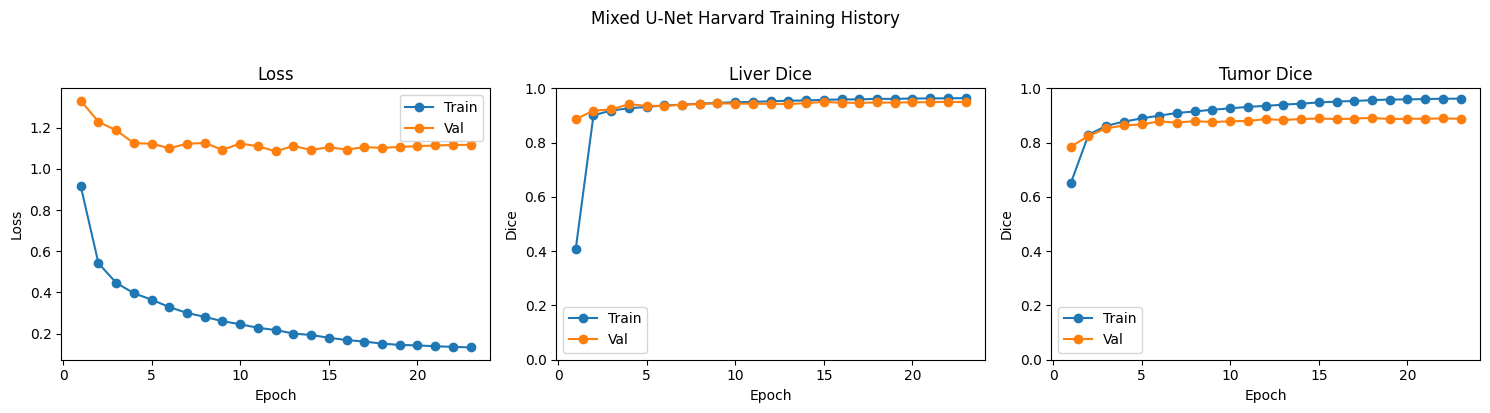

In [12]:
history_df = pd.DataFrame(all_results[0]['history'])
display(history_df.tail())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_liver'], marker='o', label='Train')
axes[1].plot(history_df['epoch'], history_df['val_liver'], marker='o', label='Val')
axes[1].set_title('Liver Dice')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice')
axes[1].set_ylim(0, 1.0)
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['train_tumor'], marker='o', label='Train')
axes[2].plot(history_df['epoch'], history_df['val_tumor'], marker='o', label='Val')
axes[2].set_title('Tumor Dice')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Dice')
axes[2].set_ylim(0, 1.0)
axes[2].legend()

fig.suptitle('Mixed U-Net Harvard Training History', y=1.02)
fig.tight_layout()
plt.show()


## How To Use This Result Next

Once this notebook finishes, place the saved `mixed_unet` result beside:

1. your plain Harvard baseline
2. your `RIU-Net` run
3. your final dependency-aware Harvard model

That gives you a clean same-dataset comparison between:

- a standard U-Net-family baseline
- a residual-Inception-style recent baseline (`RIU-Net`)
- a hybrid 3D/2D recent baseline (`Mixed U-Net`)
- your final explicit dependency-aware model

### Recommended next comparison order

1. finish this `Mixed U-Net` Harvard notebook
2. collect the final `RIU-Net` Harvard result
3. place both beside your dependency-aware result
4. build the Harvard controlled-comparison table

This notebook is meant to satisfy the remaining same-dataset architecture comparison requested for Harvard.
